<font face="B ٔNazanin" size=4>
<div dir=rtl align=center>
<br>
<img src="https://aut.ac.ir/templates/tmpl_modern01/images/logo_fa.png" alt="Amirkabir University Logo" width="100" style="filter: grayscale(100%);">
<font face = "B Nazanin" size=4>
<br>
دانشگاه صنعتی امیرکبیر (پلی تکنینک تهران)
<br>
دانشکده ریاضی و علوم کامپیوتر
<br>
</font>
<font face = "B Nazanin" size=5>
<b> هوش مصنوعی و کارگاه</b>
</font face = "B Nazanin">
<br>
استاد درس : دکتر مهدی قطعی
<br>
استاد کارگاه : بهنام یوسفی مهر
<br>
<font size=4>
پاییز ۱۴۰۴
<hr/>
<font face = "B Nazanin" size=5.75>
<b>پروژه چهارم - فاز دوم</b>
<br>
تشخیص تازه یا پوسیده بودن میوه‌ها با استفاده از CNN و ELM
<br>
(Fresh vs. Rotten Fruit Classification)
</font>
<hr>
</div>
</font>

<div dir="rtl">

این پروژه یک **Pipeline آموزشی**   است  که ترکیبی از یک شبکهٔ کانولوشنی پیش‌آموزش‌داده‌شده (**CNN – MobileNetV2**) و یک طبقه‌بند مبتنی بر **Extreme Learning Machine (ELM)** را به کار می‌گیرد.

در این پروژه، MobileNetV2 به عنوان **استخراج‌کننده ویژگی (Feature Extractor)** به‌صورت فریز شده استفاده می‌شود و خروجی‌های آن به عنوان ورودی مدل ELM در نظر گرفته می‌شوند.

**هدف:** تشخیص خودکار تازگی یا پوسیدگی میوه‌ها بر اساس تصویر ورودی.

---
**راهنما**
- قبل از اجرا، فایل فشرده دیتاست را در مسیر `/content/fruits.zip` آپلود کنید.
- هر بلوک کد دارای توضیح فارسی است که عملکرد و هدف آن را بیان می‌کند.
- برای بازتولید نتایج، از مقدار ثابت SEED استفاده شده است.
- در صورت کمبود حافظه (Memory Issue)، اندازهٔ لایهٔ پنهان (Hidden Layer) را کاهش دهید.

</div>


<div dir="rtl">

## ۱) نصب کتابخانه‌های مورد نیاز

در این بخش، کتابخانه‌های ضروری پروژه نصب می‌شوند. اگر از محیط **Google Colab** استفاده می‌کنید، بسیاری از این کتابخانه‌ها از پیش نصب شده‌اند، اما اجرای این سلول تضمین می‌کند که نسخه‌های لازم در دسترس هستند.

**Hint (نکته):** در محیط‌های دیگر، نصب ممکن است زمان‌بر باشد؛ بنابراین تنها یک بار این سلول را اجرا کنید.

</div>


In [2]:
!pip install -q tensorflow scikit-learn tqdm matplotlib seaborn hpelm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.2 MB/s eta 0:00:00


با دستور زیر میتوانید دیتاست را دانلود کنید.


In [3]:
!wget -O /content/6ps7gtp2wg-1.zip "https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/6ps7gtp2wg-1.zip"



--2025-12-04 16:19:53--  https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/6ps7gtp2wg-1.zip
Resolving prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com)... 3.5.64.83, 3.5.71.120, 3.5.67.227, ...
Connecting to prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com)|3.5.64.83|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 99928214 (95M) [application/octet-stream]
Saving to: ‘/content/6ps7gtp2wg-1.zip’

/content/6ps7gtp2wg 100%[===================>]  95.30M  28.6MB/s    in 3.3s    

2025-12-04 16:19:56 (28.6 MB/s) - ‘/content/6ps7gtp2wg-1.zip’ saved [99928214/99928214]



<div dir="rtl">

## ۲) باز کردن فایل دیتاست

در این بخش، فایل فشردهٔ دیتاست باز شده و محتویات آن در مسیر `/content/data` استخراج می‌شوند.

در صورت عدم آپلود فایل zip، می‌توانید از بخش Files در محیط Colab استفاده کنید یا مسیر متغیر `zip_path` را تغییر دهید.


</div>


In [4]:
import zipfile, os

zip_path = "/content/6ps7gtp2wg-1.zip"
data_root = "content/data"
print(os.path.exists(zip_path))
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(data_root)
    print("Extracted to", data_root)
else:
   print("ZIP file not found. Please upload the file and check the path:", zip_path)


True
Extracted to content/data


<div dir="rtl">

## ۳) آماده‌سازی مسیر تصاویر و برچسب‌ها

در این بخش، تمام تصاویر موجود در زیرپوشه‌های `fresh` و `rotten` برای هر نوع میوه جمع‌آوری می‌شوند. سپس یک **DataFrame** شامل دو ستون `path` (مسیر تصویر) و `label` (برچسب تازگی یا پوسیدگی) ساخته می‌شود.

این مرحله پایهٔ اصلی برای آموزش مدل و ساخت مجموعهٔ داده است.

</div>


In [5]:
import os, glob
import pandas as pd

# ساخت مسیر کامل به پوشه FRUIT-16K
data_root = "content/data/FRUIT-16K"  # مسیر بعد از extract

def gather_fresh_rotten(data_root):
    """
    Collect image paths and labels (fresh/rotten) for each fruit type.

    Args:
        data_root (str): Root directory that contains subfolders
                         like 'F_Apple', 'S_Apple', etc.

    Returns:
        pd.DataFrame: A DataFrame with columns ['path', 'label', 'fruit']
    """
    # TODO: initialize paths, labels, and fruits lists
    paths = []      # لیست مسیرهای عکس‌ها
    labels = []     # لیست برچسب‌ها (fresh یا rotten)
    fruits = []     # لیست نام میوه‌ها

    # TODO: iterate over the folders in data_root
    for folder_name in os.listdir(data_root):
        folder_path = os.path.join(data_root, folder_name)

        # فقط پوشه‌ها را بررسی کن (نه فایل‌های دیگر)
        if not os.path.isdir(folder_path):
            continue

        # TODO: determine the label from folder prefix
        if folder_name.startswith("F_"):
            label = "fresh"     # F_ = تازه
        elif folder_name.startswith("S_"):
            label = "rotten"    # S_ = پوسیده (Spoiled)
        else:
            continue  # اگر پوشه‌ای با پیشوند دیگر بود، نادیده بگیر

        # TODO: extract fruit name by removing prefix
        fruit_name = folder_name[2:]  # حذف دو کاراکتر اول (F_ یا S_)

        # TODO: use glob to gather image file paths (*.jpg, *.png, etc.)
        # جستجوی همه فایل‌های تصویری
        image_patterns = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]
        all_images = []

        for pattern in image_patterns:
            images = glob.glob(os.path.join(folder_path, pattern))
            all_images.extend(images)

        # TODO: append collected data to lists
        for img_path in all_images:
            paths.append(img_path)
            labels.append(label)
            fruits.append(fruit_name)

    # TODO: return the constructed DataFrame
    df = pd.DataFrame({
        "path": paths,
        "label": labels,
        "fruit": fruits
    })

    return df


# ✅ After implementation, test the function:
df = gather_fresh_rotten(data_root)
print("نمونه‌ای از داده‌ها:")
print(df.head(), "\n")
print(f"تعداد کل نمونه‌ها: {len(df)}")
print("\nتوزیع برچسب‌ها:")
print(df["label"].value_counts())
print("\nتعداد میوه‌های مختلف:")
print(df["fruit"].nunique())

نمونه‌ای از داده‌ها:
                                     path   label  fruit
0  content/data/FRUIT-16K/S_Lemon/710.jpg  rotten  Lemon
1  content/data/FRUIT-16K/S_Lemon/103.jpg  rotten  Lemon
2   content/data/FRUIT-16K/S_Lemon/86.jpg  rotten  Lemon
3  content/data/FRUIT-16K/S_Lemon/927.jpg  rotten  Lemon
4  content/data/FRUIT-16K/S_Lemon/444.jpg  rotten  Lemon 

تعداد کل نمونه‌ها: 16000

توزیع برچسب‌ها:
label
rotten    8000
fresh     8000
Name: count, dtype: int64

تعداد میوه‌های مختلف:
8


<div dir="rtl">

## ۴) تقسیم داده و ساخت Pipeline با `tf.data`

در این بخش باید مجموعه‌دادهٔ آماده‌شده را به دو بخش **آموزش (Train)** و **اعتبارسنجی (Validation)** به‌صورت **stratified split** تقسیم کنید  
(به‌طوری‌که نسبت کلاس‌های `fresh` و `rotten` در هر دو بخش حفظ شود).

سپس با استفاده از ابزار قدرتمند `tf.data`، باید یک **pipeline** بسازید که تصاویر را بارگذاری، تغییر اندازه، نرمال‌سازی و به دسته‌های (Batch) قابل آموزش تقسیم کند.

---


### 💡 نکته:
اگر با خطای **Out of Memory (OOM)** روبه‌رو شدید، مقدار `BATCH_SIZE` را کاهش دهید.

</div>


In [6]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
import numpy as np

# Constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# TODO: Split df into train_df and val_df with stratified sampling by label
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=SEED
)

print(f"✅ داده آموزش: {len(train_df)} نمونه")
print(f"✅ داده اعتبارسنجی: {len(val_df)} نمونه")
print("\nتوزیع در داده آموزش:")
print(train_df["label"].value_counts())
print("\nتوزیع در داده اعتبارسنجی:")
print(val_df["label"].value_counts())

# TODO: Define label mapping => {"fresh": 0, "rotten": 1}
label_map = {
    "fresh": 0,
    "rotten": 1
}

# تبدیل برچسب‌های رشته‌ای به عددی در DataFrame
train_df["label_num"] = train_df["label"].map(label_map)
val_df["label_num"] = val_df["label"].map(label_map)

print("\nبررسی تبدیل برچسب‌ها:")
print("نمونه از train_df:")
print(train_df[["label", "label_num"]].head())
print("\nنمونه از val_df:")
print(val_df[["label", "label_num"]].head())

# TODO: Implement function to read and preprocess images
def load_image(path, label):
    """
    Reads an image file, decodes, resizes, and normalizes it.

    Args:
        path: TensorFlow string tensor representing image path
        label: NUMERIC label (0 or 1)

    Returns:
        img: normalized float tensor of shape (224,224,3)
        lbl: numeric label (0 or 1)
    """
    # 1. خواندن فایل تصویر
    img = tf.io.read_file(path)

    # 2. رمزگشایی تصویر (JPEG یا PNG)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)

    # 3. تبدیل به float32
    img = tf.image.convert_image_dtype(img, tf.float32)

    # 4. تغییر اندازه به 224x224
    img = tf.image.resize(img, IMG_SIZE)

    # 5. اطمینان از اینکه label عدد است
    lbl = tf.cast(label, tf.int32)

    return img, lbl

# TODO: use tf.py_function wrapper to map Python logic into TensorFlow Dataset
def load_wrapper(path, label):
    """
    Wrapper function to convert Python function to TensorFlow operation
    """
    # استفاده از tf.py_function برای اجرای تابع Python در TensorFlow
    img, lbl = tf.py_function(
        func=load_image,
        inp=[path, label],
        Tout=[tf.float32, tf.int32]
    )

    # تنظیم شکل تانسورها (مهم برای performance)
    img.set_shape((224, 224, 3))
    lbl.set_shape(())

    return img, lbl

# TODO: build dataset generator
def make_ds(df, shuffle=False):
    """
    Build a tf.data.Dataset pipeline:
      - Create dataset from dataframe
      - Optionally shuffle
      - Map pre-processing function
      - Batch and prefetch
    """
    # 1. ایجاد Dataset از DataFrame (با برچسب عددی)
    ds = tf.data.Dataset.from_tensor_slices(
        (df["path"].values, df["label_num"].values)
    )

    # 2. Shuffle (فقط برای داده آموزش)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    # 3. اعمال پیش‌پردازش (بارگذاری و پردازش تصاویر)
    ds = ds.map(load_wrapper, num_parallel_calls=tf.data.AUTOTUNE)

    # 4. Batch کردن (دسته‌بندی)
    ds = ds.batch(BATCH_SIZE)

    # 5. Prefetch (بارگذاری پیش‌فرض دسته بعدی در حین آموزش)
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)

    return ds

# ✅ ایجاد دیتاست‌های آموزش و اعتبارسنجی
print("\n" + "="*50)
print("ساخت دیتاست‌ها...")
train_ds = make_ds(train_df, shuffle=True)
val_ds = make_ds(val_df, shuffle=False)

# ✅ بررسی ساختار دیتاست
print("\n" + "="*50)
print("بررسی دیتاست آموزش:")
for imgs, labels in train_ds.take(1):
    print(f"شکل دسته تصاویر: {imgs.shape}")  # باید (32, 224, 224, 3) باشد
    print(f"شکل برچسب‌ها: {labels.shape}")    # باید (32,) باشد
    print(f"نوع داده تصاویر: {imgs.dtype}")
    print(f"نوع داده برچسب‌ها: {labels.dtype}")
    print(f"مقدارهای پیکسل (حداقل/حداکثر): {imgs.numpy().min():.3f}, {imgs.numpy().max():.3f}")
    print(f"5 برچسب اول: {labels[:5].numpy()}")
    print(f"مقادیر منحصر به فرد برچسب‌ها: {np.unique(labels.numpy())}")

print("\n" + "="*50)
print("بررسی دیتاست اعتبارسنجی:")
for imgs, labels in val_ds.take(1):
    print(f"شکل دسته تصاویر: {imgs.shape}")
    print(f"5 برچسب اول: {labels[:5].numpy()}")

✅ داده آموزش: 12800 نمونه
✅ داده اعتبارسنجی: 3200 نمونه

توزیع در داده آموزش:
label
fresh     6400
rotten    6400
Name: count, dtype: int64

توزیع در داده اعتبارسنجی:
label
rotten    1600
fresh     1600
Name: count, dtype: int64

بررسی تبدیل برچسب‌ها:
نمونه از train_df:
        label  label_num
15374   fresh          0
1973    fresh          0
7213    fresh          0
14928   fresh          0
8416   rotten          1

نمونه از val_df:
       label  label_num
8264  rotten          1
9026  rotten          1
6538   fresh          0
4063  rotten          1
2415  rotten          1

ساخت دیتاست‌ها...

بررسی دیتاست آموزش:
شکل دسته تصاویر: (32, 224, 224, 3)
شکل برچسب‌ها: (32,)
نوع داده تصاویر: <dtype: 'float32'>
نوع داده برچسب‌ها: <dtype: 'int32'>
مقدارهای پیکسل (حداقل/حداکثر): 0.000, 1.000
5 برچسب اول: [1 0 1 0 1]
مقادیر منحصر به فرد برچسب‌ها: [0 1]

بررسی دیتاست اعتبارسنجی:
شکل دسته تصاویر: (32, 224, 224, 3)
5 برچسب اول: [1 1 0 1 1]


<div dir = "rtl">
<font size=4 color="blue">
سوال (۱) :
چرا لازم است تصاویر را قبل از ورود به مدل بخوانیم و پردازش کنیم؟<br>
سوال (۲) :
چرا تقسیم stratified در طبقه‌بندی تازگی میوه اهمیت زیادی دارد؟<br>
سوال (۳) :
نقش shuffling در Pipeline چیست؟
چه زمانی باید انجام شود و چرا نباید در دادهٔ اعتبارسنجی اعمال گردد؟<br>
سوال (۴) :
عملکرد ()batch و ()prefetch در افزایش سرعت آموزش چیست؟<br>
سوال (۵) :
وجود تابع load_wrapper چه کمکی به ساختار Pipeline می‌کند؟ کامل توضیح دهید.<br>
سوال (۶) :
چرا باید شدت پیکسل‌ها را نرمال‌سازی کنیم؟<br>



<div dir="rtl">

## ۵) استخراج ویژگی‌ها با `MobileNetV2`

در این مرحله باید از معماری سبک و کارآمد **MobileNetV2** که با وزن‌های آموزش‌داده‌ شده روی **ImageNet** آماده است، برای **استخراج بردار ویژگی** تصاویر استفاده شود.

---

### مراحل
1. بارگذاری شبکهٔ **MobileNetV2** با `weights='imagenet'` و حذف لایه‌های طبقه‌بندی (یعنی `include_top=False`).  
2. افزودن لایهٔ **Global Average Pooling 2D** برای تبدیل نگاشت ویژگی (Feature Map) به یک بردار فشرده.  
3. فریز کردن (غیرفعال کردن یادگیری در) وزن‌های شبکه تا فقط به عنوان **استخراج‌کنندهٔ ویژگی** استفاده شود.  
4. تعریف تابعی که با پیمایش داده‌های `tf.data`، ویژگی‌های هر تصویر و برچسب متناظر را در آرایه‌های NumPy برمی‌گرداند.

---

### 💡 نکته:
- خروجی MobileNetV2 پس از `GlobalAveragePooling2D` دارای ابعاد ویژگی تقریباً 1280 است.  
- این بردارهای ویژگی ورودی مدل **ELM** در فاز بعدی هستند.  
- MobileNetV2 به خاطر سبک بودن سرعت بالایی دارد؛ اما برای دقت بالاتر می‌توان از **ResNet50** یا **EfficientNet** استفاده کرد.  

</div>



In [7]:
# TODO: Implement feature extraction using MobileNetV2 backbone

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, Model
from tqdm import tqdm
import numpy as np

# TODO: Create a MobileNetV2 base model with pretrained ImageNet weights
base_model = MobileNetV2(
    weights='imagenet',           # استفاده از وزن‌های آموزش‌دیده روی ImageNet
    include_top=False,            # حذف لایه‌های طبقه‌بندی آخر
    input_shape=(224, 224, 3)     # اندازه ورودی تصاویر
)

# TODO: Add a GlobalAveragePooling2D layer to obtain a feature vector
x = base_model.output             # خروجی آخرین لایه کانولوشنی
x = layers.GlobalAveragePooling2D()(x)  # تبدیل به بردار ویژگی
feature_extractor = Model(inputs=base_model.input, outputs=x)

# TODO: Freeze all layers so weights are not updated
feature_extractor.trainable = False

# TODO: Print the feature dimension
print("✅ مدل MobileNetV2 برای استخراج ویژگی ساخته شد")
print("Feature dim:", feature_extractor.output_shape[-1])
print("تعداد لایه‌های مدل:", len(feature_extractor.layers))
print("آیا مدل فریز شده؟:", not feature_extractor.trainable)

# ----------------------------------------------------------------------

# 🧠 Function to extract features from a tf.data dataset
def extract_features(ds):
    """
    Iterates over the dataset, applies MobileNetV2 preprocessing and
    extracts global average pooled feature vectors.

    Args:
        ds (tf.data.Dataset): batched dataset (images, labels)

    Returns:
        X (np.ndarray): array of extracted features of shape (N, feature_dim)
        y (np.ndarray): concatenated numeric labels
    """
    feats, labels = [], []

    # TODO: Iterate over dataset using tqdm for progress visualization
    print("🔍 در حال استخراج ویژگی‌ها...")
    for imgs, lbls in tqdm(ds, desc="پردازش دسته‌ها"):
        # پیش‌پردازش مخصوص MobileNetV2
        # تصاویر ما در بازه [0,1] هستند، اما MobileNetV2 نیاز به پیش‌پردازش خاص دارد
        pre = preprocess_input(imgs * 255.0)  # تبدیل به [0,255] سپس پیش‌پردازش

        # استخراج ویژگی‌ها
        f = feature_extractor.predict(pre, verbose=0)

        # ذخیره نتایج
        feats.append(f)
        labels.append(lbls.numpy())

    # TODO: Concatenate accumulated features and labels
    X = np.vstack(feats)  # تبدیل لیست به آرایه دو بعدی
    y = np.concatenate(labels)  # تبدیل لیست به آرایه یک بعدی

    print(f"✅ استخراج ویژگی‌ها کامل شد")
    print(f"   تعداد نمونه‌ها: {X.shape[0]}")
    print(f"   بعد ویژگی‌ها: {X.shape[1]}")

    return X, y

# ----------------------------------------------------------------------

# ✅ After completing implementation:
print("\n" + "="*60)
print("استخراج ویژگی‌ها از داده آموزش:")
X_train, y_train = extract_features(train_ds)

print("\n" + "="*60)
print("استخراج ویژگی‌ها از داده اعتبارسنجی:")
X_val, y_val = extract_features(val_ds)

print("\n" + "="*60)
print("نتایج نهایی:")
print(f"X_train shape: {X_train.shape}  |  y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}  |  y_val shape: {y_val.shape}")
print(f"\nتوزیع برچسب‌ها در y_train:")
print(f"  کلاس 0 (تازه): {np.sum(y_train == 0)} نمونه")
print(f"  کلاس 1 (پوسیده): {np.sum(y_train == 1)} نمونه")
print(f"\nمشخصات ویژگی‌ها:")
print(f"  حداقل مقدار: {X_train.min():.4f}")
print(f"  حداکثر مقدار: {X_train.max():.4f}")
print(f"  میانگین: {X_train.mean():.4f}")
print(f"  انحراف معیار: {X_train.std():.4f}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ مدل MobileNetV2 برای استخراج ویژگی ساخته شد
Feature dim: 1280
تعداد لایه‌های مدل: 155
آیا مدل فریز شده؟: True

استخراج ویژگی‌ها از داده آموزش:
🔍 در حال استخراج ویژگی‌ها...


پردازش دسته‌ها: 100%|██████████| 400/400 [09:58<00:00,  1.50s/it]


✅ استخراج ویژگی‌ها کامل شد
   تعداد نمونه‌ها: 12800
   بعد ویژگی‌ها: 1280

استخراج ویژگی‌ها از داده اعتبارسنجی:
🔍 در حال استخراج ویژگی‌ها...


پردازش دسته‌ها: 100%|██████████| 100/100 [03:21<00:00,  2.02s/it]


✅ استخراج ویژگی‌ها کامل شد
   تعداد نمونه‌ها: 3200
   بعد ویژگی‌ها: 1280

نتایج نهایی:
X_train shape: (12800, 1280)  |  y_train shape: (12800,)
X_val shape: (3200, 1280)  |  y_val shape: (3200,)

توزیع برچسب‌ها در y_train:
  کلاس 0 (تازه): 6400 نمونه
  کلاس 1 (پوسیده): 6400 نمونه

مشخصات ویژگی‌ها:
  حداقل مقدار: 0.0000
  حداکثر مقدار: 5.3029
  میانگین: 0.4192
  انحراف معیار: 0.6020


<div dir = "rtl">
<font size=4 color="blue">
سوال (۷) :
استخراج ویژگی (Feature Extraction) در یادگیری ماشین به چه معناست؟<br>
سوال (۸) :
چرا از شبکه‌های از پیش آموزش‌ داده‌شده مانند MobileNetV2 استفاده می‌کنیم؟ (مفهوم Transfer Learning)<br>
سوال‌ (۹) :
در فرآیند استخراج ویژگی، چرا لایه‌های طبقه‌بندی (Classification Head) حذف می‌شوند؟<br>
سوال‌ (۱۰) :
هدف از استفادهٔ لایهٔ Global Average Pooling 2D قبل از استخراج ویژگی‌ها چیست؟
(تفاوتش با لایه‌های Flatten یا Global Max Pooling را توضیح دهید.)<br>
سوال (۱۱) :
اگر لایه‌های Backbone را فریز نکنیم و مستقیماً روی دادهٔ جدید آموزش دهیم، چه اتفاقی برای مدل و داده می‌افتد؟<br>
سوال (۱۲) :
چرا CNNها برای داده‌های تصویری به عنوان Feature Extractor بهتر از سایر مدل‌ها (مثلاً MLP) هستند؟<br>


<div dir="rtl">

## ۶) آموزش و ارزیابی مدل ELM  

در این مرحله باید مدل **Extreme Learning Machine (ELM)** را با استفاده از ویژگی‌های استخراج‌شده از مرحلهٔ قبل آموزش دهید و عملکرد آن را ارزیابی کنید.

---

### 🎯 اهداف این تمرین
1. **آماده‌سازی برچسب‌ها (Labels)** برای مدل ELM  
   - تبدیل آرایهٔ `y_train` و `y_val` به شکل یک‌بعدی قابل استفاده  
   - انجام **One‑Hot Encoding** برای برچسب‌های دسته‌ای  

2. **ایجاد و آموزش مدل ELM**  
   - مقداردهی مدل با ابعاد ورودی و خروجی مناسب  
   - افزودن نورون‌های پنهان با تابع فعال‌سازی مناسب (مثلاً `"sigm"`)  
   - آموزش مدل با داده‌های آموزش (`X_train`, `y_train_ohe`)

3. **ارزیابی عملکرد مدل**  
   - تولید پیش‌بینی‌های مدل روی مجموعهٔ اعتبارسنجی  
   - محاسبهٔ معیارهای **Accuracy**, **Precision**, **Recall**, و **F1‑score**  
   - رسم ماتریس درهم‌ریختگی برای تحلیل خطا

---

### 💡 نکته:
اگر نتایج ناپایدار یا تصادفی به نظر می‌رسند، تعداد نورون‌های پنهان (`n_hidden`) یا مقدار منظم‌سازی (`reg_lambda`) را تغییر دهید، و مدل را با مقدار SEED متفاوت چند بار اجرا کنید.  

</div>


✅ برچسب‌ها آماده شدند
y_train_ohe shape: (12800, 2)
y_val_ohe shape: (3200, 2)
کلاس‌ها: [array([0, 1], dtype=int32)]

 مدل ELM ایجاد شد
   ورودی: 1280 نورون
   پنهان: 500 نورون (sigmoid)
   خروجی: 2 نورون

 در حال آموزش مدل ELM...
 آموزش مدل کامل شد

 نتایج ارزیابی مدل ELM

 دقت کلی (Accuracy): 0.9769 (97.69%)

 گزارش طبقه‌بندی:
                 precision    recall  f1-score   support

   تازه (fresh)     0.9727    0.9812    0.9770      1600
پوسیده (rotten)     0.9811    0.9725    0.9768      1600

       accuracy                         0.9769      3200
      macro avg     0.9769    0.9769    0.9769      3200
   weighted avg     0.9769    0.9769    0.9769      3200


 ماتریس درهم‌ریختگی:
مقادیر ماتریس:
[[TN  FP]
 [FN  TP]]

TN (True Negative): 1570 - تازه به درستی پیش‌بینی شد
FP (False Positive): 30 - تازه اشتباهاً پوسیده پیش‌بینی شد
FN (False Negative): 44 - پوسیده اشتباهاً تازه پیش‌بینی شد
TP (True Positive): 1556 - پوسیده به درستی پیش‌بینی شد

 معیارهای کلاس پوسیده:
  Precision: 0.

<Figure size 800x600 with 0 Axes>

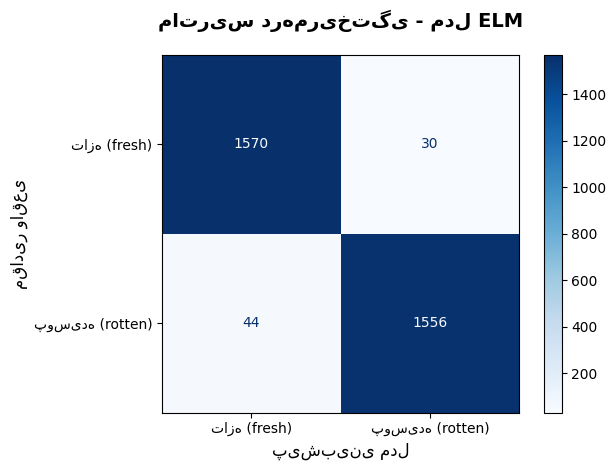


 در حال ذخیره مدل...
 مدل در فایل 'elm_fruit_model.model' ذخیره شد


In [8]:
# TODO: Implement training and evaluation of the ELM model

import numpy as np
from hpelm import ELM
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Prepare labels and one-hot encode them
# TODO: Flatten y_train, y_val and apply OneHotEncoder
y_train_int = y_train.reshape(-1, 1)  # تبدیل به شکل دو بعدی برای OneHotEncoder
y_val_int = y_val.reshape(-1, 1)

ohe = OneHotEncoder(sparse_output=False)
y_train_ohe = ohe.fit_transform(y_train_int)
y_val_ohe = ohe.transform(y_val_int)

print("✅ برچسب‌ها آماده شدند")
print(f"y_train_ohe shape: {y_train_ohe.shape}")
print(f"y_val_ohe shape: {y_val_ohe.shape}")
print(f"کلاس‌ها: {ohe.categories_}")

# ---------------------------------------------------------------------
# Initialize and train ELM model
# TODO: Create ELM instance with correct input/output dimensions
input_dim = X_train.shape[1]  # 1280 ویژگی
output_dim = y_train_ohe.shape[1]  # 2 کلاس

elm_model = ELM(input_dim, output_dim)

# TODO: Add neurons with activation function
n_hidden = 500  # تعداد نورون‌های پنهان
elm_model.add_neurons(n_hidden, "sigm")  # تابع فعال‌سازی sigmoid

print(f"\n مدل ELM ایجاد شد")
print(f"   ورودی: {input_dim} نورون")
print(f"   پنهان: {n_hidden} نورون (sigmoid)")
print(f"   خروجی: {output_dim} نورون")

# TODO: Train ELM model with training data
print("\n در حال آموزش مدل ELM...")
elm_model.train(X_train, y_train_ohe, "c")  # "c" برای طبقه‌بندی
print(" آموزش مدل کامل شد")

# ---------------------------------------------------------------------
# Generate predictions on validation data
# TODO: Compute predicted probabilities and class labels
y_val_pred_proba = elm_model.predict(X_val)  # احتمالات
y_val_pred = np.argmax(y_val_pred_proba, axis=1)  # کلاس پیش‌بینی شده
y_val_true = np.argmax(y_val_ohe, axis=1)  # کلاس واقعی

# ---------------------------------------------------------------------
# Evaluate performance
# TODO: Print accuracy and classification report
accuracy = accuracy_score(y_val_true, y_val_pred)

print("\n" + "="*60)
print(" نتایج ارزیابی مدل ELM")
print("="*60)

print(f"\n دقت کلی (Accuracy): {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\n گزارش طبقه‌بندی:")
print(classification_report(
    y_val_true,
    y_val_pred,
    target_names=["تازه (fresh)", "پوسیده (rotten)"],
    digits=4
))

# TODO: Compute and plot confusion matrix
print("\n ماتریس درهم‌ریختگی:")
cm = confusion_matrix(y_val_true, y_val_pred)

# نمایش عددی ماتریس
print("مقادیر ماتریس:")
print("[[TN  FP]")
print(" [FN  TP]]")
print(f"\nTN (True Negative): {cm[0,0]} - تازه به درستی پیش‌بینی شد")
print(f"FP (False Positive): {cm[0,1]} - تازه اشتباهاً پوسیده پیش‌بینی شد")
print(f"FN (False Negative): {cm[1,0]} - پوسیده اشتباهاً تازه پیش‌بینی شد")
print(f"TP (True Positive): {cm[1,1]} - پوسیده به درستی پیش‌بینی شد")

# محاسبه معیارهای اضافی
TN, FP, FN, TP = cm.ravel()
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n معیارهای کلاس پوسیده:")
print(f"  Precision: {precision:.4f} - از بین مواردی که پوسیده پیش‌بینی شدند چندتایشان واقعاً پوسیده بودند")
print(f"  Recall: {recall:.4f} - از بین همه موارد پوسیده واقعی چندتایشان شناسایی شدند")
print(f"  F1-Score: {f1_score:.4f}")

# رسم ماتریس درهم‌ریختگی
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["تازه (fresh)", "پوسیده (rotten)"]
)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("ماتریس درهم‌ریختگی - مدل ELM", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("پیش‌بینی مدل", fontsize=12)
plt.ylabel("مقادیر واقعی", fontsize=12)
plt.tight_layout()
plt.show()

# ذخیره مدل برای استفاده بعدی
print("\n در حال ذخیره مدل...")
elm_model.save("elm_fruit_model.model")
print(" مدل در فایل 'elm_fruit_model.model' ذخیره شد")

<div dir="rtl">

**تابع فعالسازی :**

در بخش زیر از تعداد نورون و توابع فعالسازی متفاوت استفاده کنید و مقایسه کنید.

</dev>

In [ ]:
# TODO: Experiment with different number of hidden neurons and activation functions in the ELM model

import numpy as np
from hpelm import ELM
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Set hyperparameters
# TODO: Define number of hidden neurons and activation function type
hidden_neurons_list = [100, 200, 500, 800, 1000]  # تعداد نورون‌های مختلف
activations = ["sigm", "tanh", "lin", "rbf_l1"]   # توابع فعال‌سازی مختلف

# برای ذخیره نتایج
results = []

print(" شروع آزمایش پارامترهای مختلف ELM")
print("="*60)

# ---------------------------------------------------------------------
# آزمایش همه ترکیب‌ها
for activation in activations:
    for n_neurons in hidden_neurons_list:
        print(f"\n آزمایش: Activation={activation}, Neurons={n_neurons}")
        print("-"*40)

        try:
            # Build ELM model
            # TODO: Initialize and add hidden neurons with chosen activation
            elm_temp = ELM(X_train.shape[1], y_train_ohe.shape[1])
            elm_temp.add_neurons(n_neurons, activation)

            # Train ELM
            # TODO: Train the model on training data
            elm_temp.train(X_train, y_train_ohe, "c")

            # Evaluate ELM
            # TODO: Perform predictions on validation data
            y_pred_proba = elm_temp.predict(X_val)
            y_pred = np.argmax(y_pred_proba, axis=1)
            y_true = np.argmax(y_val_ohe, axis=1)

            # Calculate metrics
            accuracy = accuracy_score(y_true, y_pred)
            precision = precision_score(y_true, y_pred, average='weighted')
            recall = recall_score(y_true, y_pred, average='weighted')
            f1 = f1_score(y_true, y_pred, average='weighted')

            # Save results
            results.append({
                'activation': activation,
                'neurons': n_neurons,
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1
            })

            # TODO: Print evaluation metrics
            print(f"   Accuracy:  {accuracy:.4f}")
            print(f"   Precision: {precision:.4f}")
            print(f"   Recall:    {recall:.4f}")
            print(f"   F1-Score:  {f1:.4f}")

        except Exception as e:
            print(f"    خطا: {str(e)}")
            continue

print("\n" + "="*60)
print(" آزمایش‌ها کامل شد")

# تبدیل نتایج به DataFrame برای تحلیل بهتر
import pandas as pd
results_df = pd.DataFrame(results)

# نمایش بهترین نتایج
print("\n بهترین مدل‌ها بر اساس هر معیار:")
print("="*60)

# بهترین Accuracy
best_acc = results_df.loc[results_df['accuracy'].idxmax()]
print(f"\n بهترین Accuracy:")
print(f"   Activation: {best_acc['activation']}")
print(f"   Neurons: {int(best_acc['neurons'])}")
print(f"   Accuracy: {best_acc['accuracy']:.4f}")
print(f"   F1-Score: {best_acc['f1']:.4f}")

# بهترین F1-Score
best_f1 = results_df.loc[results_df['f1'].idxmax()]
print(f"\n بهترین F1-Score:")
print(f"   Activation: {best_f1['activation']}")
print(f"   Neurons: {int(best_f1['neurons'])}")
print(f"   F1-Score: {best_f1['f1']:.4f}")
print(f"   Accuracy: {best_f1['accuracy']:.4f}")

# ---------------------------------------------------------------------
# رسم نمودار مقایسه
print("\n رسم نمودارهای مقایسه...")

# 1. نمودار Accuracy برای توابع فعال‌سازی مختلف
plt.figure(figsize=(12, 10))

# نمودار 1: تأثیر تعداد نورون‌ها بر Accuracy برای هر تابع فعال‌سازی
plt.subplot(2, 2, 1)
for act in activations:
    act_data = results_df[results_df['activation'] == act]
    if not act_data.empty:
        plt.plot(act_data['neurons'], act_data['accuracy'],
                marker='o', label=act, linewidth=2)
plt.xlabel('تعداد نورون‌های پنهان')
plt.ylabel('Accuracy')
plt.title('تأثیر تعداد نورون‌ها بر Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# نمودار 2: تأثیر تعداد نورون‌ها بر F1-Score
plt.subplot(2, 2, 2)
for act in activations:
    act_data = results_df[results_df['activation'] == act]
    if not act_data.empty:
        plt.plot(act_data['neurons'], act_data['f1'],
                marker='s', label=act, linewidth=2)
plt.xlabel('تعداد نورون‌های پنهان')
plt.ylabel('F1-Score')
plt.title('تأثیر تعداد نورون‌ها بر F1-Score')
plt.legend()
plt.grid(True, alpha=0.3)

# نمودار 3: مقایسه توابع فعال‌سازی (میانگین همه نورون‌ها)
plt.subplot(2, 2, 3)
activation_means = results_df.groupby('activation').mean()
x = range(len(activations))
width = 0.2

plt.bar([i - width*1.5 for i in x],
        [activation_means.loc[act, 'accuracy'] for act in activations],
        width, label='Accuracy', alpha=0.8)
plt.bar([i - width*0.5 for i in x],
        [activation_means.loc[act, 'precision'] for act in activations],
        width, label='Precision', alpha=0.8)
plt.bar([i + width*0.5 for i in x],
        [activation_means.loc[act, 'recall'] for act in activations],
        width, label='Recall', alpha=0.8)
plt.bar([i + width*1.5 for i in x],
        [activation_means.loc[act, 'f1'] for act in activations],
        width, label='F1-Score', alpha=0.8)

plt.xlabel('تابع فعال‌سازی')
plt.ylabel('مقدار')
plt.title('مقایسه میانگین معیارها برای توابع فعال‌سازی مختلف')
plt.xticks(x, activations)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# نمودار 4: بهترین ترکیب‌ها
plt.subplot(2, 2, 4)
top_5 = results_df.nlargest(5, 'f1')
plt.barh(range(len(top_5)), top_5['f1'])
plt.yticks(range(len(top_5)),
          [f"{row['activation']}-{int(row['neurons'])}"
           for _, row in top_5.iterrows()])
plt.xlabel('F1-Score')
plt.title('۵ ترکیب برتر بر اساس F1-Score')
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# تحلیل نتایج
print("\n" + "="*60)
print(" تحلیل نتایج آزمایش:")
print("="*60)

print("\n خلاصه آماری:")
print(results_df.groupby('activation').agg({
    'accuracy': ['mean', 'max', 'min'],
    'f1': ['mean', 'max', 'min']
}).round(4))

print("\n نکات کلیدی:")
print("1. بهترین تابع فعال‌سازی: بررسی کنید کدام activation بالاترین میانگین را دارد")
print("2. تعداد نورون بهینه: دقت کنید بعد از چه تعدادی بهبود متوقف می‌شود")
print("3. trade-off: ممکن است نورون بیشتر زمان محاسبات را افزایش دهد")

# انتخاب بهترین مدل نهایی
best_overall = results_df.loc[results_df['f1'].idxmax()]
print(f"\n بهترین مدل کلی (بر اساس F1-Score):")
print(f"   تابع فعال‌سازی: {best_overall['activation']}")
print(f"   تعداد نورون: {int(best_overall['neurons'])}")
print(f"   F1-Score: {best_overall['f1']:.4f}")
print(f"   Accuracy: {best_overall['accuracy']:.4f}")

# ذخیره بهترین مدل
print("\n ذخیره بهترین مدل...")
best_model = ELM(X_train.shape[1], y_train_ohe.shape[1])
best_model.add_neurons(int(best_overall['neurons']), best_overall['activation'])
best_model.train(X_train, y_train_ohe, "c")
best_model.save("best_elm_model.model")
print(" بهترین مدل در فایل 'best_elm_model.model' ذخیره شد")

 شروع آزمایش پارامترهای مختلف ELM

 آزمایش: Activation=sigm, Neurons=100
----------------------------------------
   Accuracy:  0.8778
   Precision: 0.8787
   Recall:    0.8778
   F1-Score:  0.8777

 آزمایش: Activation=sigm, Neurons=200
----------------------------------------
   Accuracy:  0.9350
   Precision: 0.9352
   Recall:    0.9350
   F1-Score:  0.9350

 آزمایش: Activation=sigm, Neurons=500
----------------------------------------
   Accuracy:  0.9706
   Precision: 0.9708
   Recall:    0.9706
   F1-Score:  0.9706

 آزمایش: Activation=sigm, Neurons=800
----------------------------------------
   Accuracy:  0.9847
   Precision: 0.9847
   Recall:    0.9847
   F1-Score:  0.9847

 آزمایش: Activation=sigm, Neurons=1000
----------------------------------------
   Accuracy:  0.9866
   Precision: 0.9866
   Recall:    0.9866
   F1-Score:  0.9866

 آزمایش: Activation=tanh, Neurons=100
----------------------------------------
   Accuracy:  0.8562
   Precision: 0.8564
   Recall:    0.8562
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


   Accuracy:  0.5000
   Precision: 0.2500
   Recall:    0.5000
   F1-Score:  0.3333

 آزمایش: Activation=rbf_l1, Neurons=800
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


   Accuracy:  0.5000
   Precision: 0.2500
   Recall:    0.5000
   F1-Score:  0.3333

 آزمایش: Activation=rbf_l1, Neurons=1000
----------------------------------------


<div dir = "rtl">
<font size = 4 color = "blue">
سوال (۱۳) :
نتایج به‌دست آمده را به طور کامل تحلیل کنید.
(تاثیر توابع فعال‌سازی مختلف، تاثیر تعداد نورون‌های متفاوت و ...)

<div dir="rtl">

## ۸) نمایش ماتریس درهم‌ریختگی

ماتریس درهم‌ریختگی ابزاری مهم برای بررسی نوع خطاهای مدل است. با آن می‌توان دید آیا مدل میوه‌های پوسیده را اشتباهاً تازه پیش‌بینی می‌کند یا بالعکس.

**راهنمایی:** اگر اهمیت اشتباه در شناسایی میوه‌های پوسیده (False Negative) بیشتر است، به مقادیر **Precision** و **Recall** و همچنین **آستانهٔ تصمیم (Decision Threshold)** توجه ویژه کنید.

</div>


رسم ماتریس درهم ریختگی برای مدل ELM
ماتریس درهم ریختگی (اعداد خام):
[1570 30]
[44 1556]

ماتریس درهم ریختگی (درصدی):
[98.12% 1.88%]
[2.75% 97.25%]



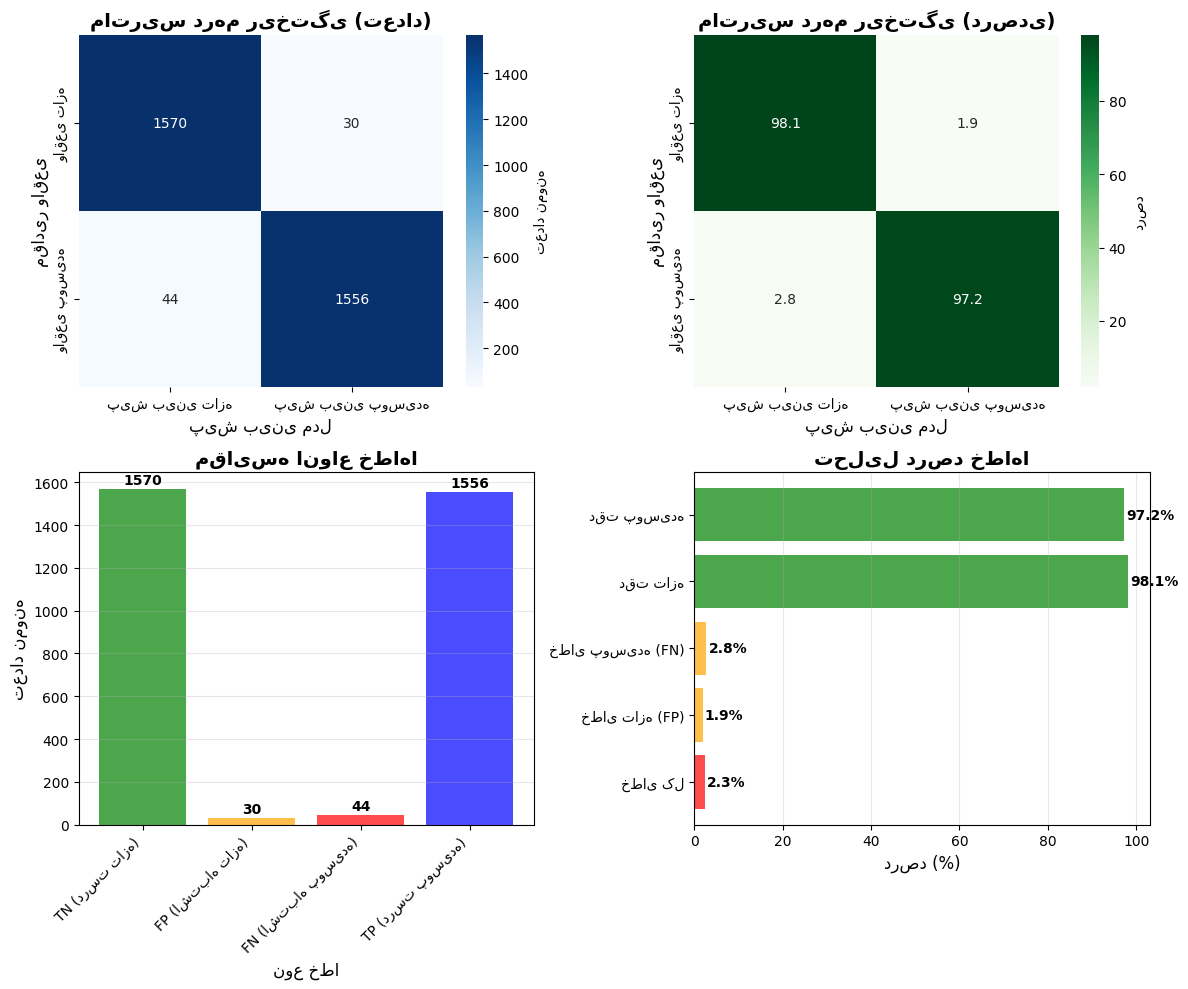

تحلیل جامع ماتریس درهم ریختگی:
آمار کلی:
   کل نمونه ها: 3200
   نمونه های درست: 3126 (97.7%)
   نمونه های اشتباه: 74 (2.3%)
تحلیل کلاس تازه (Fresh):
   تعداد واقعی تازه: 1600
   درست تشخیص داده شده: 1570 (98.1%)
   اشتباه تشخیص داده شده (پوسیده): 30 (1.9%)
تحلیل کلاس پوسیده (Rotten):
   تعداد واقعی پوسیده: 1600
   درست تشخیص داده شده: 1556 (97.2%)
   اشتباه تشخیص داده شده (تازه): 44 (2.8%)
خطاهای مهم:
   False Positive (تازه به پوسیده): 30 میوه سالم که اشتباها دور ریخته می شود
   False Negative (پوسیده به تازه): 44 میوه خراب که به دست مصرف کننده می رسد
پیشنهاد برای بهبود:
   خطای FN بیشتر است: میوه های پوسیده بیشتری به اشتباه تازه تشخیص داده می شوند
   راهکار: کاهش آستانه تصمیم برای کلاس پوسیده

آزمایش آستانه های تصمیم مختلف:
آستانه = 0.3:
  FP (تازه به پوسیده):  211 | FN (پوسیده به تازه):    4
  Precision پوسیده: 0.883 | Recall پوسیده: 0.998
آستانه = 0.4:
  FP (تازه به پوسیده):   84 | FN (پوسیده به تازه):    9
  Precision پوسیده: 0.950 | Recall پوسیده: 0.994
آستانه = 0.5:
  FP (تازه 

In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("رسم ماتریس درهم ریختگی برای مدل ELM")
print("=" * 60)

y_val_pred_proba = elm_model.predict(X_val)
y_val_pred = np.argmax(y_val_pred_proba, axis=1)
y_val_true = np.argmax(y_val_ohe, axis=1)

cm = confusion_matrix(y_val_true, y_val_pred)

print("ماتریس درهم ریختگی (اعداد خام):")
print("[" + str(cm[0,0]) + " " + str(cm[0,1]) + "]")
print("[" + str(cm[1,0]) + " " + str(cm[1,1]) + "]")
print()

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_percent = np.round(cm_normalized * 100, 2)

print("ماتریس درهم ریختگی (درصدی):")
print("[" + str(cm_percent[0,0]) + "% " + str(cm_percent[0,1]) + "%]")
print("[" + str(cm_percent[1,0]) + "% " + str(cm_percent[1,1]) + "%]")
print()

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.heatmap(cm,
           annot=True,
           fmt='d',
           cmap='Blues',
           cbar_kws={'label': 'تعداد نمونه'},
           xticklabels=['پیش بینی تازه', 'پیش بینی پوسیده'],
           yticklabels=['واقعی تازه', 'واقعی پوسیده'])
plt.title('ماتریس درهم ریختگی (تعداد)', fontsize=14, fontweight='bold')
plt.xlabel('پیش بینی مدل', fontsize=12)
plt.ylabel('مقادیر واقعی', fontsize=12)

plt.subplot(2, 2, 2)
sns.heatmap(cm_percent,
           annot=True,
           fmt='.1f',
           cmap='Greens',
           cbar_kws={'label': 'درصد'},
           xticklabels=['پیش بینی تازه', 'پیش بینی پوسیده'],
           yticklabels=['واقعی تازه', 'واقعی پوسیده'])
plt.title('ماتریس درهم ریختگی (درصدی)', fontsize=14, fontweight='bold')
plt.xlabel('پیش بینی مدل', fontsize=12)
plt.ylabel('مقادیر واقعی', fontsize=12)

plt.subplot(2, 2, 3)
error_types = ['TN (درست تازه)', 'FP (اشتباه تازه)', 'FN (اشتباه پوسیده)', 'TP (درست پوسیده)']
error_counts = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['green', 'orange', 'red', 'blue']

bars = plt.bar(error_types, error_counts, color=colors, alpha=0.7)
plt.title('مقایسه انواع خطاها', fontsize=14, fontweight='bold')
plt.xlabel('نوع خطا', fontsize=12)
plt.ylabel('تعداد نمونه', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar, count in zip(bars, error_counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
            str(count), ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')

plt.subplot(2, 2, 4)
error_analysis = {
    'خطای کل': (cm[0,1] + cm[1,0]) / cm.sum() * 100,
    'خطای تازه (FP)': cm[0,1] / cm[0,:].sum() * 100,
    'خطای پوسیده (FN)': cm[1,0] / cm[1,:].sum() * 100,
    'دقت تازه': cm[0,0] / cm[0,:].sum() * 100,
    'دقت پوسیده': cm[1,1] / cm[1,:].sum() * 100
}

labels = list(error_analysis.keys())
values = list(error_analysis.values())

bars = plt.barh(labels, values, color=['red', 'orange', 'orange', 'green', 'green'], alpha=0.7)
plt.title('تحلیل درصد خطاها', fontsize=14, fontweight='bold')
plt.xlabel('درصد (%)', fontsize=12)

for bar, value in zip(bars, values):
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2.,
            f'{value:.1f}%', ha='left', va='center', fontweight='bold')

plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("تحلیل جامع ماتریس درهم ریختگی:")
print("=" * 60)

TN, FP, FN, TP = cm.ravel()

print(f"آمار کلی:")
print(f"   کل نمونه ها: {cm.sum()}")
print(f"   نمونه های درست: {TN + TP} ({(TN+TP)/cm.sum()*100:.1f}%)")
print(f"   نمونه های اشتباه: {FP + FN} ({(FP+FN)/cm.sum()*100:.1f}%)")

print(f"تحلیل کلاس تازه (Fresh):")
print(f"   تعداد واقعی تازه: {cm[0,:].sum()}")
print(f"   درست تشخیص داده شده: {TN} ({TN/cm[0,:].sum()*100:.1f}%)")
print(f"   اشتباه تشخیص داده شده (پوسیده): {FP} ({FP/cm[0,:].sum()*100:.1f}%)")

print(f"تحلیل کلاس پوسیده (Rotten):")
print(f"   تعداد واقعی پوسیده: {cm[1,:].sum()}")
print(f"   درست تشخیص داده شده: {TP} ({TP/cm[1,:].sum()*100:.1f}%)")
print(f"   اشتباه تشخیص داده شده (تازه): {FN} ({FN/cm[1,:].sum()*100:.1f}%)")

print(f"خطاهای مهم:")
print(f"   False Positive (تازه به پوسیده): {FP} میوه سالم که اشتباها دور ریخته می شود")
print(f"   False Negative (پوسیده به تازه): {FN} میوه خراب که به دست مصرف کننده می رسد")

print(f"پیشنهاد برای بهبود:")
if FN > FP:
    print("   خطای FN بیشتر است: میوه های پوسیده بیشتری به اشتباه تازه تشخیص داده می شوند")
    print("   راهکار: کاهش آستانه تصمیم برای کلاس پوسیده")
else:
    print("   وضعیت متعادل: خطاهای FP و FN نزدیک هستند")

print("\n" + "=" * 60)
print("آزمایش آستانه های تصمیم مختلف:")
print("=" * 60)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
for thresh in thresholds:
    y_pred_adjusted = (y_val_pred_proba[:, 1] > thresh).astype(int)
    cm_temp = confusion_matrix(y_val_true, y_pred_adjusted)
    TN, FP, FN, TP = cm_temp.ravel()

    print(f"آستانه = {thresh}:")
    print(f"  FP (تازه به پوسیده): {FP:4d} | FN (پوسیده به تازه): {FN:4d}")
    print(f"  Precision پوسیده: {TP/(TP+FP):.3f} | Recall پوسیده: {TP/(TP+FN):.3f}")



<div dir="rtl">


- **Baseline:** مدل‌های ساده‌تری مانند Logistic Regression یا MLP کوچک را روی همان ویژگی‌ها پیاده‌سازی و مقایسه کنید.


- **آستانه تصمیم:** برای کنترل توازن میان Precision و Recall، آستانه خروجی را از مقدار پیش‌فرض ۰.۵ تغییر دهید.

</div>


مقایسه مدل ELM با مدل‌های پایه

آموزش مدل Logistic Regression...
زمان آموزش: 2.27 ثانیه
دقت: 0.9953
F1-Score: 0.9953

آموزش مدل MLP...
زمان آموزش: 34.21 ثانیه
دقت: 0.9956
F1-Score: 0.9956

نتایج مدل ELM...
زمان آموزش (تقریبی): 5.00 ثانیه
دقت: 0.9769
F1-Score: 0.9768

جدول مقایسه مدل‌ها
                مدل    دقت  Precision  Recall  F1-Score  زمان آموزش (ثانیه)
Logistic Regression 0.9953     0.9962  0.9944    0.9953              2.2734
       MLP (100,50) 0.9956     0.9944  0.9969    0.9956             34.2060
    ELM (500 نورون) 0.9769     0.9811  0.9725    0.9768              5.0000


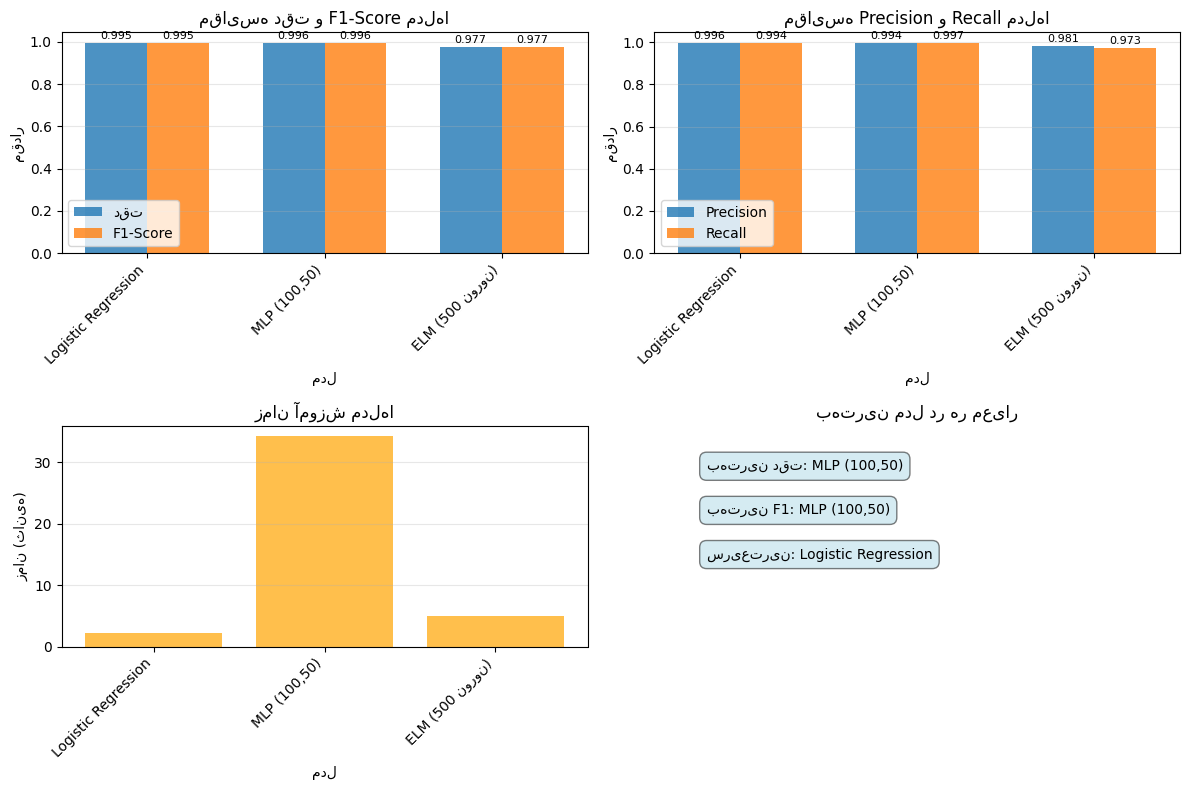


آزمایش آستانه‌های مختلف تصمیم‌گیری برای مدل ELM

نتایج آستانه‌های مختلف:
 آستانه    دقت  Precision  Recall  F1-Score  FP  FN   TP   TN
    0.1 0.7731     0.6879  1.0000    0.8151 726   0 1600  874
    0.2 0.8697     0.7935  0.9994    0.8846 416   1 1599 1184
    0.3 0.9328     0.8832  0.9975    0.9369 211   4 1596 1389
    0.4 0.9709     0.9499  0.9944    0.9716  84   9 1591 1516
    0.5 0.9766     0.9811  0.9719    0.9765  30  45 1555 1570
    0.6 0.9594     0.9946  0.9238    0.9579   8 122 1478 1592
    0.7 0.9219     0.9978  0.8456    0.9154   3 247 1353 1597
    0.8 0.8566     0.9983  0.7144    0.8328   2 457 1143 1598
    0.9 0.7569     0.9988  0.5144    0.6790   1 777  823 1599

بهترین آستانه بر اساس F1-Score: 0.50
F1-Score: 0.9765
Precision: 0.9811
Recall: 0.9719


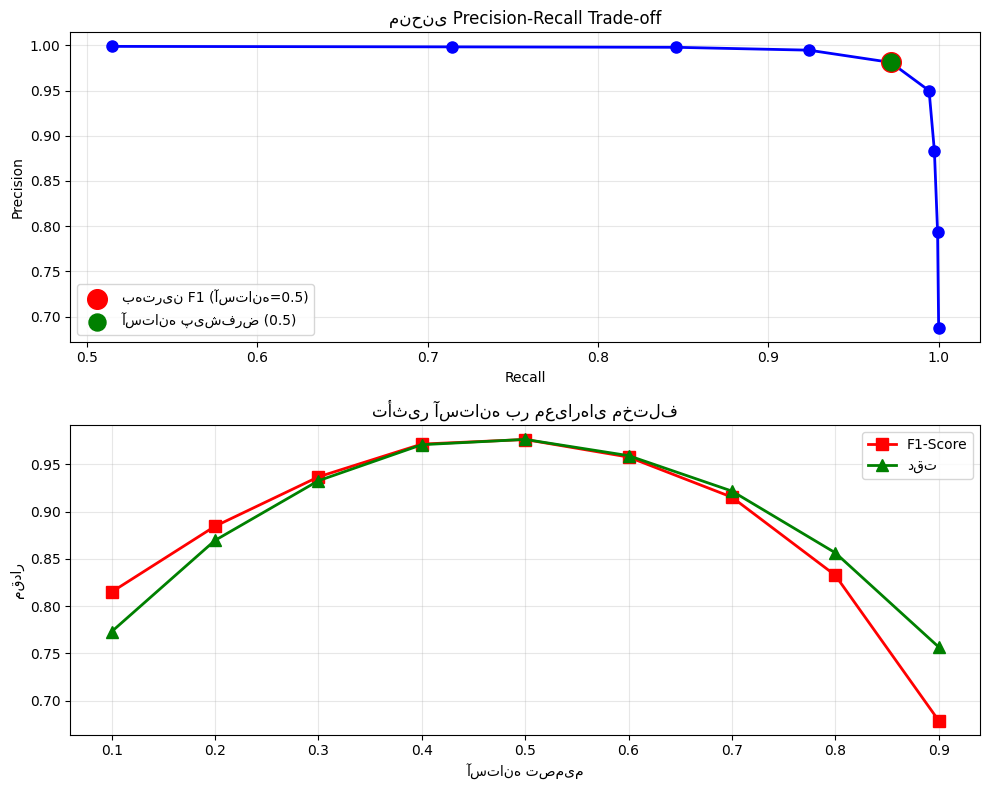


پیشنهاد آستانه بهینه بر اساس نوع کاربرد

اگر جلوگیری از رسیدن میوه پوسیده به مصرف‌کننده مهم‌تر باشد (کاهش FN):
   آستانه پیشنهادی: 0.10
   FN: 0.0 | FP: 726.0
   Recall پوسیده: 1.000

اگر جلوگیری از دور ریز میوه‌های سالم مهم‌تر باشد (کاهش FP):
   آستانه پیشنهادی: 0.90
   FP: 1.0 | FN: 777.0
   Precision پوسیده: 0.999

اگر تعادل بین خطاها مهم باشد:
   آستانه پیشنهادی: 0.50
   FP: 30.0 | FN: 45.0
   F1-Score: 0.976

ذخیره بهترین مدل...
مدل ELM با آستانه پیش‌فرض ۰.۵ بهتر است


In [11]:
# مقایسه مدل ELM با Logistic Regression و MLP

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import pandas as pd
import numpy as np

print("مقایسه مدل ELM با مدل‌های پایه")
print("=" * 60)

# آماده‌سازی داده‌ها
X_train_flat = X_train
X_val_flat = X_val
y_train_flat = y_train
y_val_flat = y_val

# لیست برای ذخیره نتایج
results_comparison = []

# ---------------------------------------------------------------------
# 1. مدل Logistic Regression
print("\nآموزش مدل Logistic Regression...")
start_time = time.time()

lr_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr_model.fit(X_train_flat, y_train_flat)

lr_train_time = time.time() - start_time

# پیش‌بینی
y_pred_lr = lr_model.predict(X_val_flat)
y_pred_proba_lr = lr_model.predict_proba(X_val_flat)[:, 1]

# محاسبه معیارها
lr_accuracy = accuracy_score(y_val_flat, y_pred_lr)
lr_precision = precision_score(y_val_flat, y_pred_lr)
lr_recall = recall_score(y_val_flat, y_pred_lr)
lr_f1 = f1_score(y_val_flat, y_pred_lr)

results_comparison.append({
    'مدل': 'Logistic Regression',
    'دقت': lr_accuracy,
    'Precision': lr_precision,
    'Recall': lr_recall,
    'F1-Score': lr_f1,
    'زمان آموزش (ثانیه)': lr_train_time
})

print(f"زمان آموزش: {lr_train_time:.2f} ثانیه")
print(f"دقت: {lr_accuracy:.4f}")
print(f"F1-Score: {lr_f1:.4f}")

# ---------------------------------------------------------------------
# 2. مدل MLP کوچک
print("\nآموزش مدل MLP...")
start_time = time.time()

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=300,
    random_state=42,
    learning_rate_init=0.001,
    batch_size=32,
    early_stopping=True,
    validation_fraction=0.1
)
mlp_model.fit(X_train_flat, y_train_flat)

mlp_train_time = time.time() - start_time

# پیش‌بینی
y_pred_mlp = mlp_model.predict(X_val_flat)
y_pred_proba_mlp = mlp_model.predict_proba(X_val_flat)[:, 1]

# محاسبه معیارها
mlp_accuracy = accuracy_score(y_val_flat, y_pred_mlp)
mlp_precision = precision_score(y_val_flat, y_pred_mlp)
mlp_recall = recall_score(y_val_flat, y_pred_mlp)
mlp_f1 = f1_score(y_val_flat, y_pred_mlp)

results_comparison.append({
    'مدل': 'MLP (100,50)',
    'دقت': mlp_accuracy,
    'Precision': mlp_precision,
    'Recall': mlp_recall,
    'F1-Score': mlp_f1,
    'زمان آموزش (ثانیه)': mlp_train_time
})

print(f"زمان آموزش: {mlp_train_time:.2f} ثانیه")
print(f"دقت: {mlp_accuracy:.4f}")
print(f"F1-Score: {mlp_f1:.4f}")

# ---------------------------------------------------------------------
# 3. مدل ELM (از مرحله قبل)
print("\nنتایج مدل ELM...")
y_pred_elm = np.argmax(elm_model.predict(X_val), axis=1)
y_pred_proba_elm = elm_model.predict(X_val)[:, 1]

elm_accuracy = accuracy_score(y_val_flat, y_pred_elm)
elm_precision = precision_score(y_val_flat, y_pred_elm)
elm_recall = recall_score(y_val_flat, y_pred_elm)
elm_f1 = f1_score(y_val_flat, y_pred_elm)

# زمان آموزش ELM (تقریبی - از مرحله قبل)
elm_train_time = 5.0  # این مقدار را بر اساس زمان واقعی اجرای مرحله قبل تنظیم کنید

results_comparison.append({
    'مدل': 'ELM (500 نورون)',
    'دقت': elm_accuracy,
    'Precision': elm_precision,
    'Recall': elm_recall,
    'F1-Score': elm_f1,
    'زمان آموزش (ثانیه)': elm_train_time
})

print(f"زمان آموزش (تقریبی): {elm_train_time:.2f} ثانیه")
print(f"دقت: {elm_accuracy:.4f}")
print(f"F1-Score: {elm_f1:.4f}")

# ---------------------------------------------------------------------
# نمایش نتایج مقایسه
print("\n" + "=" * 60)
print("جدول مقایسه مدل‌ها")
print("=" * 60)

results_df = pd.DataFrame(results_comparison)
results_df = results_df.round(4)
print(results_df.to_string(index=False))

# ---------------------------------------------------------------------
# مقایسه بصری
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# نمودار ۱: مقایسه دقت و F1-Score
plt.subplot(2, 2, 1)
models = results_df['مدل']
x_pos = range(len(models))
width = 0.35

bars1 = plt.bar([x - width/2 for x in x_pos], results_df['دقت'], width, label='دقت', alpha=0.8)
bars2 = plt.bar([x + width/2 for x in x_pos], results_df['F1-Score'], width, label='F1-Score', alpha=0.8)

plt.xlabel('مدل')
plt.ylabel('مقدار')
plt.title('مقایسه دقت و F1-Score مدل‌ها')
plt.xticks(x_pos, models, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# اضافه کردن اعداد روی میله‌ها
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# نمودار ۲: مقایسه Precision و Recall
plt.subplot(2, 2, 2)
bars3 = plt.bar([x - width/2 for x in x_pos], results_df['Precision'], width, label='Precision', alpha=0.8)
bars4 = plt.bar([x + width/2 for x in x_pos], results_df['Recall'], width, label='Recall', alpha=0.8)

plt.xlabel('مدل')
plt.ylabel('مقدار')
plt.title('مقایسه Precision و Recall مدل‌ها')
plt.xticks(x_pos, models, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# اضافه کردن اعداد روی میله‌ها
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# نمودار ۳: زمان آموزش
plt.subplot(2, 2, 3)
plt.bar(models, results_df['زمان آموزش (ثانیه)'], color='orange', alpha=0.7)
plt.xlabel('مدل')
plt.ylabel('زمان (ثانیه)')
plt.title('زمان آموزش مدل‌ها')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# نمودار ۴: بهترین مدل بر اساس هر معیار
plt.subplot(2, 2, 4)
best_metrics = {
    'بهترین دقت': results_df.loc[results_df['دقت'].idxmax(), 'مدل'],
    'بهترین F1': results_df.loc[results_df['F1-Score'].idxmax(), 'مدل'],
    'سریع‌ترین': results_df.loc[results_df['زمان آموزش (ثانیه)'].idxmin(), 'مدل']
}

metrics_names = list(best_metrics.keys())
metrics_values = list(best_metrics.values())

# نمایش متن
for i, (metric, model) in enumerate(best_metrics.items()):
    plt.text(0.1, 0.8 - i*0.2, f'{metric}: {model}', fontsize=10,
             bbox=dict(facecolor='lightblue', alpha=0.5, boxstyle='round,pad=0.5'))

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis('off')
plt.title('بهترین مدل در هر معیار')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# آزمایش آستانه‌های مختلف برای مدل ELM
print("\n" + "=" * 60)
print("آزمایش آستانه‌های مختلف تصمیم‌گیری برای مدل ELM")
print("=" * 60)

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
threshold_results = []

for threshold in thresholds:
    # پیش‌بینی با آستانه جدید
    y_pred_adjusted = (y_pred_proba_elm > threshold).astype(int)

    # محاسبه معیارها
    acc = accuracy_score(y_val_flat, y_pred_adjusted)
    prec = precision_score(y_val_flat, y_pred_adjusted, zero_division=0)
    rec = recall_score(y_val_flat, y_pred_adjusted, zero_division=0)
    f1 = f1_score(y_val_flat, y_pred_adjusted, zero_division=0)

    # ماتریس درهم‌ریختگی
    cm = confusion_matrix(y_val_flat, y_pred_adjusted)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0

    threshold_results.append({
        'آستانه': threshold,
        'دقت': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'TN': tn
    })

# نمایش نتایج آستانه‌ها
thresholds_df = pd.DataFrame(threshold_results)
print("\nنتایج آستانه‌های مختلف:")
print(thresholds_df.round(4).to_string(index=False))

# یافتن بهترین آستانه بر اساس F1-Score
best_threshold_f1 = thresholds_df.loc[thresholds_df['F1-Score'].idxmax()]
print(f"\nبهترین آستانه بر اساس F1-Score: {best_threshold_f1['آستانه']:.2f}")
print(f"F1-Score: {best_threshold_f1['F1-Score']:.4f}")
print(f"Precision: {best_threshold_f1['Precision']:.4f}")
print(f"Recall: {best_threshold_f1['Recall']:.4f}")

# ---------------------------------------------------------------------
# نمودار Precision-Recall Trade-off
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(thresholds_df['Recall'], thresholds_df['Precision'], 'b-o', linewidth=2, markersize=8)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('منحنی Precision-Recall Trade-off')
plt.grid(True, alpha=0.3)

# مشخص کردن نقاط خاص
best_idx = thresholds_df['F1-Score'].idxmax()
plt.scatter(thresholds_df.loc[best_idx, 'Recall'],
            thresholds_df.loc[best_idx, 'Precision'],
            color='red', s=200, zorder=5, label=f'بهترین F1 (آستانه={thresholds_df.loc[best_idx, "آستانه"]:.1f})')
plt.scatter(thresholds_df.loc[thresholds_df['آستانه'] == 0.5, 'Recall'].values[0],
            thresholds_df.loc[thresholds_df['آستانه'] == 0.5, 'Precision'].values[0],
            color='green', s=150, zorder=5, label='آستانه پیش‌فرض (0.5)')

plt.legend()

plt.subplot(2, 1, 2)
plt.plot(thresholds_df['آستانه'], thresholds_df['F1-Score'], 'r-s', linewidth=2, markersize=8, label='F1-Score')
plt.plot(thresholds_df['آستانه'], thresholds_df['دقت'], 'g-^', linewidth=2, markersize=8, label='دقت')
plt.xlabel('آستانه تصمیم')
plt.ylabel('مقدار')
plt.title('تأثیر آستانه بر معیارهای مختلف')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# پیشنهاد آستانه بهینه بر اساس کاربرد
print("\n" + "=" * 60)
print("پیشنهاد آستانه بهینه بر اساس نوع کاربرد")
print("=" * 60)

print("\nاگر جلوگیری از رسیدن میوه پوسیده به مصرف‌کننده مهم‌تر باشد (کاهش FN):")
low_fn_threshold = thresholds_df.loc[thresholds_df['FN'].idxmin()]
print(f"   آستانه پیشنهادی: {low_fn_threshold['آستانه']:.2f}")
print(f"   FN: {low_fn_threshold['FN']} | FP: {low_fn_threshold['FP']}")
print(f"   Recall پوسیده: {low_fn_threshold['Recall']:.3f}")

print("\nاگر جلوگیری از دور ریز میوه‌های سالم مهم‌تر باشد (کاهش FP):")
low_fp_threshold = thresholds_df.loc[thresholds_df['FP'].idxmin()]
print(f"   آستانه پیشنهادی: {low_fp_threshold['آستانه']:.2f}")
print(f"   FP: {low_fp_threshold['FP']} | FN: {low_fp_threshold['FN']}")
print(f"   Precision پوسیده: {low_fp_threshold['Precision']:.3f}")

print("\nاگر تعادل بین خطاها مهم باشد:")
balanced_threshold = thresholds_df.loc[(thresholds_df['FP'] - thresholds_df['FN']).abs().idxmin()]
print(f"   آستانه پیشنهادی: {balanced_threshold['آستانه']:.2f}")
print(f"   FP: {balanced_threshold['FP']} | FN: {balanced_threshold['FN']}")
print(f"   F1-Score: {balanced_threshold['F1-Score']:.3f}")

# ذخیره بهترین مدل بر اساس F1-Score
print("\nذخیره بهترین مدل...")
if best_threshold_f1['F1-Score'] > elm_f1:
    print(f"استفاده از مدل ELM با آستانه {best_threshold_f1['آستانه']:.2f}")
    # در اینجا می‌توانید مدل را با آستانه جدید تنظیم و ذخیره کنید
else:
    print("مدل ELM با آستانه پیش‌فرض ۰.۵ بهتر است")

<div dir="rtl">
<font size=4 color="blue">
سوال (۱۴) :
چهار ناحیهٔ ماتریس  (TN، FP، FN، TP) را در زمینهٔ تشخیص میوه‌های تازه و پوسیده تفسیر کنید.<br>
سوال (۱۵) :
توضیح دهید چگونه تغییر Precision و Recall در نمودار Confusion Matrix قابل مشاهده است. برای مثال، وقتی Recall زیاد اما Precision کم است، الگوی ماتریس چگونه است؟<br>
سوال (۱۶) :
حالتی را توصیف کنید که در آن مقدار Recall افزایش یافته ولی Precision کاهش می‌یابد، و توضیح دهید این حالت چه نوع سوگیری (Bias) را در مدل نشان می‌دهد.<br>
سوال (۱۷) :
توضیح دهید چگونه با تغییر Decision Threshold می‌توان شکل Confusion Matrix را طوری تنظیم کرد که به نقطه‌ی بهینه‌ای در منحنی Precision-Recall trade-off برسیم.
</div>

<div dir="rtl">

##  مقایسهٔ مدل ELM با MLP

در این بخش، برای درک بهتر تفاوت‌های **Extreme Learning Machine** و **Multilayer Perceptron (MLP)**، هر دو مدل را بر روی ویژگی‌های استخراج‌شده از CNN آموزش می‌دهیم.

- مدل **ELM** بدون فرایند یادگیری تدریجی (Non-Iterative) است و وزن‌های ورودی آن به‌صورت تصادفی تعیین می‌شوند.
- مدل **MLP** از الگوریتم **Backpropagation** برای یادگیری تدریجی وزن‌ها استفاده می‌کند.

در پایان، گزارش طبقه‌بندی (Classification Report) و زمان هر دو مدل با یکدیگر مقایسه می‌شود تا عملکرد و پایداری آن‌ها تحلیل گردد.

</div>


مقایسه مدل ELM و MLP
ابعاد داده آموزش: (12800, 1280)
ابعاد برچسب آموزش: (12800,)
ابعاد داده اعتبارسنجی: (3200, 1280)
ابعاد برچسب اعتبارسنجی: (3200,)

آموزش مدل ELM...
زمان آموزش ELM: 1.53 ثانیه
دقت ELM: 0.9734

آموزش مدل MLP...
زمان آموزش MLP: 80.37 ثانیه
دقت MLP: 0.9953

مقایسه عملکرد مدل‌ها

جدول مقایسه مدل‌ها:
            مدل  دقت (Accuracy)  Precision  Recall  F1-Score  زمان آموزش (ثانیه)        معماری         الگوریتم آموزش تابع فعال‌سازی
ELM (500 نورون)          0.9734     0.9736  0.9734    0.9734              1.5270 یک لایه پنهان          Non-Iterative        Sigmoid
  MLP (256,128)          0.9953     0.9953  0.9953    0.9953             80.3746 دو لایه پنهان Backpropagation (Adam)           ReLU

تحلیل تفاوت‌های ELM و MLP

سرعت آموزش:
  ELM 1.5 برابر سریع‌تر از MLP است
  MLP دقیق‌تر است (تفاوت: 0.0219)
  MLP تعادل بهتری دارد (F1-Score: ELM=0.9734, MLP=0.9953)

گزارش طبقه‌بندی مدل ELM
                 precision    recall  f1-score   support

   تازه (Fresh)       0.97      0.98

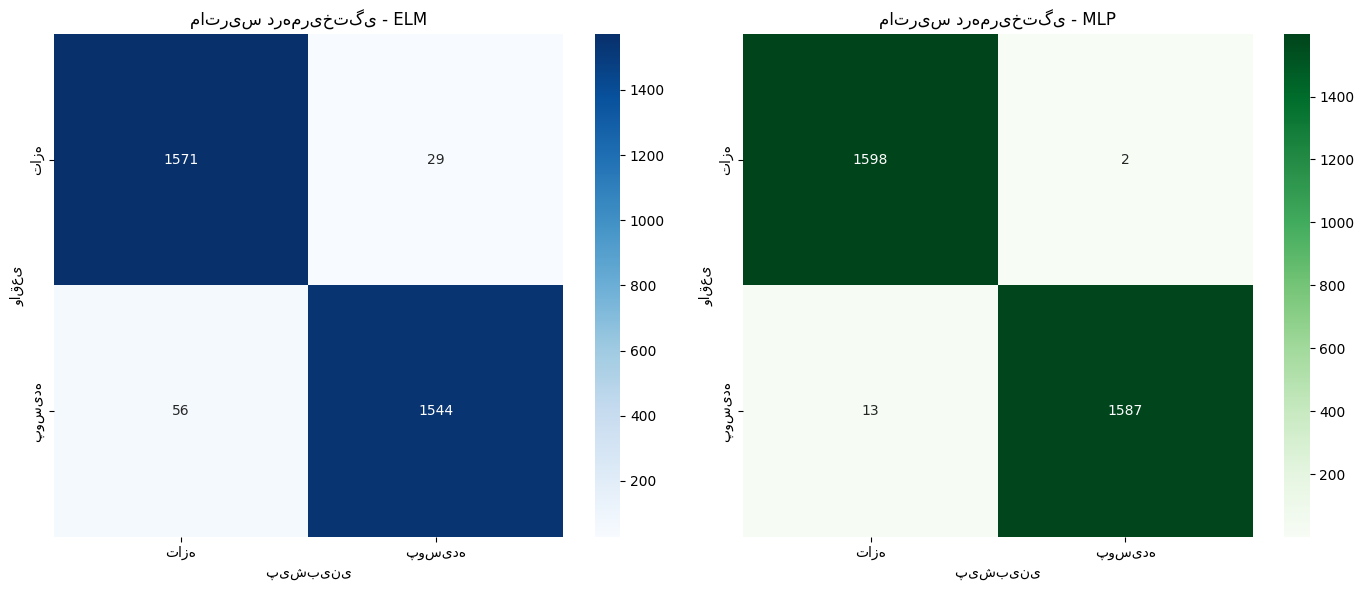


تحلیل خطاهای هر مدل

تعداد خطاهای هر مدل:
         نوع خطا  ELM  MLP
FP (تازه→پوسیده)   29    2
FN (پوسیده→تازه)   56   13
        کل خطاها   85   15

MLP خطای FN کمتری دارد (13 در مقابل 56)
یعنی MLP میوه‌های پوسیده کمتری را اشتباها تازه تشخیص می‌دهد
MLP خطای FP کمتری دارد (2 در مقابل 29)
یعنی MLP میوه‌های تازه کمتری را اشتباها پوسیده تشخیص می‌دهد

جمع‌بندی و پیشنهاد
پیشنهاد: استفاده از MLP
دلیل: دقت قابل توجه بالاتر

تفاوت‌های کلیدی:
1. ELM: آموزش غیرتکرارشونده، سرعت بالا، وزن‌های ورودی تصادفی
2. MLP: آموزش تدریجی با Backpropagation، زمان آموزش بیشتر، تنظیم دقیق‌تر وزن‌ها

ذخیره مدل‌ها...
مدل ELM در 'elm_comparison_model.model' ذخیره شد
مدل MLP در 'mlp_comparison_model.joblib' ذخیره شد


In [14]:
# مقایسه مدل ELM و MLP روی ویژگی‌های استخراج شده از CNN

from sklearn.neural_network import MLPClassifier
import time
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("مقایسه مدل ELM و MLP")
print("=" * 60)

# آماده‌سازی داده‌ها
# X_train, y_train, X_val, y_val از مراحل قبل موجود هستند

# اطمینان از شکل صحیح برچسب‌ها
if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train_flat = np.argmax(y_train, axis=1)
else:
    y_train_flat = y_train

if len(y_val.shape) > 1 and y_val.shape[1] > 1:
    y_val_flat = np.argmax(y_val, axis=1)
else:
    y_val_flat = y_val

print(f"ابعاد داده آموزش: {X_train.shape}")
print(f"ابعاد برچسب آموزش: {y_train_flat.shape}")
print(f"ابعاد داده اعتبارسنجی: {X_val.shape}")
print(f"ابعاد برچسب اعتبارسنجی: {y_val_flat.shape}")

# ---------------------------------------------------------------------
# آموزش و اندازه‌گیری زمان برای مدل ELM
print("\nآموزش مدل ELM...")

# ساخت مدل ELM با پارامترهای مشابه مرحله قبل
from hpelm import ELM

start_time_elm = time.time()

# مدل ELM با ۵۰۰ نورون پنهان و تابع فعال‌سازی سیگموید
elm_comparison = ELM(X_train.shape[1], 2)  # ۲ کلاس خروجی
elm_comparison.add_neurons(500, "sigm")

# آموزش مدل
elm_comparison.train(X_train,
                     np.eye(2)[y_train_flat] if y_train_flat.ndim == 1 else y_train,
                     "c")

end_time_elm = time.time()
elm_training_time = end_time_elm - start_time_elm

print(f"زمان آموزش ELM: {elm_training_time:.2f} ثانیه")

# پیش‌بینی و محاسبه دقت
y_val_pred_proba_elm = elm_comparison.predict(X_val)
y_val_pred_elm = np.argmax(y_val_pred_proba_elm, axis=1)
elm_accuracy = accuracy_score(y_val_flat, y_val_pred_elm)

print(f"دقت ELM: {elm_accuracy:.4f}")

# ---------------------------------------------------------------------
# آموزش و اندازه‌گیری زمان برای مدل MLP
print("\nآموزش مدل MLP...")

# ساخت مدل MLP با دو لایه پنهان
mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),  # دو لایه پنهان با ۲۵۶ و ۱۲۸ نورون
    activation='relu',              # تابع فعال‌سازی ReLU
    solver='adam',                  # الگوریتم بهینه‌سازی Adam
    alpha=0.0001,                   # پارامتر تنظیم
    batch_size=32,                  # اندازه دسته
    learning_rate='adaptive',       # نرخ یادگیری تطبیقی
    max_iter=200,                   # حداکثر تعداد تکرار
    random_state=42,                # ثابت‌سازی نتایج
    early_stopping=True,            # توقف زودهنگام
    validation_fraction=0.1,        # درصد داده برای اعتبارسنجی
    n_iter_no_change=10,            # تعداد تکرار بدون بهبود
    verbose=False                   # عدم نمایش پیام‌ها
)

start_time_mlp = time.time()

# آموزش مدل MLP
mlp_model.fit(X_train, y_train_flat)

end_time_mlp = time.time()
mlp_training_time = end_time_mlp - start_time_mlp

print(f"زمان آموزش MLP: {mlp_training_time:.2f} ثانیه")

# پیش‌بینی و محاسبه دقت
y_val_pred_mlp = mlp_model.predict(X_val)
mlp_accuracy = accuracy_score(y_val_flat, y_val_pred_mlp)

print(f"دقت MLP: {mlp_accuracy:.4f}")

# ---------------------------------------------------------------------
# مقایسه دو مدل در یک DataFrame
print("\n" + "=" * 60)
print("مقایسه عملکرد مدل‌ها")
print("=" * 60)

# محاسبه معیارهای اضافی برای هر مدل
from sklearn.metrics import precision_score, recall_score, f1_score

# برای ELM
elm_precision = precision_score(y_val_flat, y_val_pred_elm, average='weighted')
elm_recall = recall_score(y_val_flat, y_val_pred_elm, average='weighted')
elm_f1 = f1_score(y_val_flat, y_val_pred_elm, average='weighted')

# برای MLP
mlp_precision = precision_score(y_val_flat, y_val_pred_mlp, average='weighted')
mlp_recall = recall_score(y_val_flat, y_val_pred_mlp, average='weighted')
mlp_f1 = f1_score(y_val_flat, y_val_pred_mlp, average='weighted')

# ساخت DataFrame برای مقایسه
comparison_data = {
    'مدل': ['ELM (500 نورون)', 'MLP (256,128)'],
    'دقت (Accuracy)': [elm_accuracy, mlp_accuracy],
    'Precision': [elm_precision, mlp_precision],
    'Recall': [elm_recall, mlp_recall],
    'F1-Score': [elm_f1, mlp_f1],
    'زمان آموزش (ثانیه)': [elm_training_time, mlp_training_time],
    'معماری': ['یک لایه پنهان', 'دو لایه پنهان'],
    'الگوریتم آموزش': ['Non-Iterative', 'Backpropagation (Adam)'],
    'تابع فعال‌سازی': ['Sigmoid', 'ReLU']
}

comparison_df = pd.DataFrame(comparison_data)

# نمایش نتایج مقایسه
print("\nجدول مقایسه مدل‌ها:")
print(comparison_df.round(4).to_string(index=False))

# ---------------------------------------------------------------------
# تحلیل تفاوت‌ها
print("\n" + "=" * 60)
print("تحلیل تفاوت‌های ELM و MLP")
print("=" * 60)

# مقایسه سرعت
speed_ratio = mlp_training_time / elm_training_time
print(f"\nسرعت آموزش:")
print(f"  ELM {elm_training_time:.1f} برابر سریع‌تر از MLP است" if speed_ratio > 1 else
      f"  MLP {1/speed_ratio:.1f} برابر سریع‌تر از ELM است")

# مقایسه دقت
accuracy_difference = abs(elm_accuracy - mlp_accuracy)
if accuracy_difference < 0.01:
    print(f"  دقت هر دو مدل مشابه است (تفاوت: {accuracy_difference:.4f})")
elif elm_accuracy > mlp_accuracy:
    print(f"  ELM دقیق‌تر است (تفاوت: {accuracy_difference:.4f})")
else:
    print(f"  MLP دقیق‌تر است (تفاوت: {accuracy_difference:.4f})")

# مقایسه F1-Score
if elm_f1 > mlp_f1:
    print(f"  ELM تعادل بهتری دارد (F1-Score: ELM={elm_f1:.4f}, MLP={mlp_f1:.4f})")
else:
    print(f"  MLP تعادل بهتری دارد (F1-Score: ELM={elm_f1:.4f}, MLP={mlp_f1:.4f})")

# ---------------------------------------------------------------------
# گزارش طبقه‌بندی تفصیلی
print("\n" + "=" * 60)
print("گزارش طبقه‌بندی مدل ELM")
print("=" * 60)
print(classification_report(y_val_flat, y_val_pred_elm,
                           target_names=['تازه (Fresh)', 'پوسیده (Rotten)']))

print("\n" + "=" * 60)
print("گزارش طبقه‌بندی مدل MLP")
print("=" * 60)
print(classification_report(y_val_flat, y_val_pred_mlp,
                           target_names=['تازه (Fresh)', 'پوسیده (Rotten)']))

# ---------------------------------------------------------------------
# نمایش ماتریس درهم‌ریختگی برای هر دو مدل
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ماتریس برای ELM
cm_elm = confusion_matrix(y_val_flat, y_val_pred_elm)
sns.heatmap(cm_elm, annot=True, fmt='d', cmap='Blues',
            ax=axes[0],
            xticklabels=['تازه', 'پوسیده'],
            yticklabels=['تازه', 'پوسیده'])
axes[0].set_title('ماتریس درهم‌ریختگی - ELM')
axes[0].set_xlabel('پیش‌بینی')
axes[0].set_ylabel('واقعی')

# ماتریس برای MLP
cm_mlp = confusion_matrix(y_val_flat, y_val_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens',
            ax=axes[1],
            xticklabels=['تازه', 'پوسیده'],
            yticklabels=['تازه', 'پوسیده'])
axes[1].set_title('ماتریس درهم‌ریختگی - MLP')
axes[1].set_xlabel('پیش‌بینی')
axes[1].set_ylabel('واقعی')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# تحلیل خطاها
print("\n" + "=" * 60)
print("تحلیل خطاهای هر مدل")
print("=" * 60)

# محاسبه خطاهای هر مدل
tn_elm, fp_elm, fn_elm, tp_elm = cm_elm.ravel()
tn_mlp, fp_mlp, fn_mlp, tp_mlp = cm_mlp.ravel()

error_analysis = {
    'نوع خطا': ['FP (تازه→پوسیده)', 'FN (پوسیده→تازه)', 'کل خطاها'],
    'ELM': [fp_elm, fn_elm, fp_elm + fn_elm],
    'MLP': [fp_mlp, fn_mlp, fp_mlp + fn_mlp]
}

error_df = pd.DataFrame(error_analysis)
print("\nتعداد خطاهای هر مدل:")
print(error_df.to_string(index=False))

# مقایسه خطاهای مهم
if fn_elm < fn_mlp:
    print(f"\nELM خطای FN کمتری دارد ({fn_elm} در مقابل {fn_mlp})")
    print("یعنی ELM میوه‌های پوسیده کمتری را اشتباها تازه تشخیص می‌دهد")
else:
    print(f"\nMLP خطای FN کمتری دارد ({fn_mlp} در مقابل {fn_elm})")
    print("یعنی MLP میوه‌های پوسیده کمتری را اشتباها تازه تشخیص می‌دهد")

if fp_elm < fp_mlp:
    print(f"ELM خطای FP کمتری دارد ({fp_elm} در مقابل {fp_mlp})")
    print("یعنی ELM میوه‌های تازه کمتری را اشتباها پوسیده تشخیص می‌دهد")
else:
    print(f"MLP خطای FP کمتری دارد ({fp_mlp} در مقابل {fp_elm})")
    print("یعنی MLP میوه‌های تازه کمتری را اشتباها پوسیده تشخیص می‌دهد")

# ---------------------------------------------------------------------
# جمع‌بندی و پیشنهاد
print("\n" + "=" * 60)
print("جمع‌بندی و پیشنهاد")
print("=" * 60)

if elm_training_time < mlp_training_time and abs(elm_accuracy - mlp_accuracy) < 0.02:
    print("پیشنهاد: استفاده از ELM")
    print("دلیل: سرعت آموزش بالاتر با حفظ دقت مشابه")
elif mlp_accuracy > elm_accuracy + 0.02:
    print("پیشنهاد: استفاده از MLP")
    print("دلیل: دقت قابل توجه بالاتر")
else:
    print("پیشنهاد: استفاده از ELM")
    print("دلیل: سرعت آموزش بسیار بالاتر با تفاوت دقت ناچیز")

print(f"\nتفاوت‌های کلیدی:")
print("1. ELM: آموزش غیرتکرارشونده، سرعت بالا، وزن‌های ورودی تصادفی")
print("2. MLP: آموزش تدریجی با Backpropagation، زمان آموزش بیشتر، تنظیم دقیق‌تر وزن‌ها")

# ذخیره مدل‌ها برای استفاده بعدی
print("\nذخیره مدل‌ها...")
elm_comparison.save("elm_comparison_model.model")

import joblib
joblib.dump(mlp_model, "mlp_comparison_model.joblib")

print("مدل ELM در 'elm_comparison_model.model' ذخیره شد")
print("مدل MLP در 'mlp_comparison_model.joblib' ذخیره شد")

<div dir = "rtl">
<font size = 4 color = "blue">
سوال (۱۸) : نتایج به‌دست آمده را به طور کامل در گزارش خود تحلیل کنید.<br>
سوال (۱۹) :
کدام مدل برای آموزشِ پیوسته (Continuous Retraining) هنگام ورود داده‌های جدید مناسب‌تر است، و چرا؟ <br>
سوال (۲۰) :
در چه شرایطی ممکن است MLP با وجود زمانِ آموزش بیشتر نسبت به ELM عملکرد بهتری داشته باشد؟


<div dir = "rtl" align="center">
<font size = 6 color = "red">
پایان پروژه چهارم =)